In [1]:
# BEHAVIORAL DRIFT DETECTION: MODEL COMPARISON STUDY
# Purpose: Compare different anomaly detection models for identifying changes in daily routines using synthetic data
# Compare four models: Isolation Forest, One-Class SVM, LSTM, Autoencoder

# Importing Libraries
import os, gc, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, confusion_matrix, precision_recall_curve, roc_curve)
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from tensorflow.keras import layers, models, callbacks

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # supress warnings

# Set visual style
plt.style.use('default')
sns.set_palette("colorblind")

#Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

#File paths
data_csv_path = Path("/content/drive/MyDrive/Dissertation/Dataset/merged_dataset.csv")

# Study Design Parameters
drift_start_day = 183   # Day when behavioral drift begins (day 1-182 = normal)
normal_days_reserved_for_testing = 60  # Last 60 normal days used for validation/testing
normal_days_for_validation = 30  # First 30 of those 60 used for validation
drift_days_for_validation = 15   # First 15 drift days used for validation

# Training windows
training_windows = [30, 90, 120]
comparison_window = 120  # Which window to use for detailed model comparisons

#Model Training Strategy
use_validation_for_threshold = False  # If False, use unsupervised approach
unsupervised_threshold_quantile = 0.99  # Used only when use_validation_for_threshold=False

# Training data selection policy
training_data_selection = "predrift"  # Use all normal days before drift starts
training_window_selection = "first"   # Use the earliest available normal days

#Model Hyperparameters
# LSTM Sequence Forecaster
sequence_length = 7  # Days of history used to predict the next day
lstm_epochs = 60
lstm_batch_size = 32
lstm_early_stopping = 8
lstm_dropout_rate = 0.20
validation_fraction = 0.10  # Fraction of training used for validation

# Autoencoder
autoencoder_epochs = 120
autoencoder_hidden_units = [64, 16]  # Encoder layer sizes
autoencoder_bottleneck_factor = 4    # Bottleneck size = n_features // factor
autoencoder_learning_rate = 1e-3

# One-Class SVM
svm_nu_setting = "auto"

#Behavioral Features to Track
key_activities = ["breakfast", "lunch", "dinner", "sleeping", "napping", "toileting"]
minimum_activity_durations = {  # Filter out unrealistically short activities
    "sleeping": 20 * 60,  # 20 minutes
    "napping": 10 * 60,   # 10 minutes
    "showering": 3 * 60,  # 3 minutes
}

In [2]:
# Load the raw activity data
activity_data = pd.read_csv(data_csv_path)

required_columns = {"global_day", "activity_name", "simulation_seconds", "time_of_the_day"}
missing_columns = required_columns - set(activity_data.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

# Clean and standardize data formats
activity_data["global_day"] = (
    pd.to_numeric(activity_data["global_day"], errors="coerce")
    .astype("Int64").ffill().bfill().astype(int)
)
activity_data["activity_name"] = activity_data["activity_name"].astype(str).str.strip()
activity_data["simulation_seconds"] = pd.to_numeric(
    activity_data["simulation_seconds"], errors="coerce"
).fillna(0).astype(int)

# Convert time to minutes since midnight for easier analysis
def time_to_minutes(time_str):
    try:
        hours, minutes = str(time_str).split(":")[:2]
        return int(hours) * 60 + int(minutes)
    except:
        return 0

activity_data["time_in_minutes"] = activity_data["time_of_the_day"].apply(time_to_minutes).astype(int)

# Sort data chronologically and identify continuous activity sessions
activity_data = activity_data.sort_values(["global_day", "simulation_seconds"]).reset_index(drop=True)
session_change = (
    (activity_data["activity_name"] != activity_data["activity_name"].shift()) |
    (activity_data["global_day"] != activity_data["global_day"].shift())
)
activity_data["session_id"] = session_change.cumsum()

# Extract session information
sessions = activity_data.groupby("session_id").agg(
    day=("global_day", "first"),
    activity=("activity_name", "first"),
    start_seconds=("simulation_seconds", "min"),
    end_seconds=("simulation_seconds", "max"),
    start_minutes=("time_in_minutes", "median")
).reset_index(drop=True)
sessions["duration_seconds"] = (sessions["end_seconds"] - sessions["start_seconds"]).clip(lower=0)

# Filter out implausibly short sessions (likely data errors)
sessions = sessions[
    sessions.apply(
        lambda row: row["duration_seconds"] >= minimum_activity_durations.get(row["activity"], 0),
        axis=1
    )
].reset_index(drop=True)


In [3]:
# Count of each key activity per day
activity_counts = sessions.groupby(["day", "activity"])["activity"].count().unstack(fill_value=0)
for activity in key_activities:
    if activity not in activity_counts.columns:
        activity_counts[activity] = 0
activity_counts = activity_counts[key_activities].sort_index()

# Night-time toileting (between midnight and 5 AM)
toileting_sessions = sessions[sessions["activity"] == "toileting"].copy()
toileting_sessions["is_night"] = (toileting_sessions["start_minutes"] < 5 * 60).astype(int)
night_toileting = toileting_sessions.groupby("day")["is_night"].sum()
activity_counts["toileting_night"] = activity_counts.index.map(night_toileting).fillna(0).astype(int)

# First occurrence time of key activities each day
first_activity_times = (
    sessions.sort_values(["day", "start_seconds"])
    .groupby(["day", "activity"])["start_minutes"].first().unstack()
)

for activity in ["breakfast", "lunch", "dinner", "sleeping"]:
    if activity not in first_activity_times.columns:
        first_activity_times[activity] = np.nan

first_activity_times = first_activity_times[["breakfast", "lunch", "dinner", "sleeping"]].reindex(activity_counts.index)

# Mark days when activities didn't occur
missing_activity_flags = first_activity_times.isna().add_prefix("missing_").astype(int)

# Total sleep time and night activity ratio
sleep_time = (
    sessions[sessions["activity"] == "sleeping"]
    .groupby("day")["duration_seconds"].sum()
).div(60)  # Convert to minutes

night_activities = sessions.assign(
    is_night=(sessions["start_minutes"] < 5 * 60).astype(int)
).groupby("day")["is_night"].sum()

total_activities = sessions.groupby("day")["activity"].count()

# Combine all features into daily profile
daily_behavior = activity_counts.copy()
daily_behavior["sleep_minutes"] = daily_behavior.index.map(sleep_time).fillna(0)
daily_behavior["night_activity_ratio"] = (
    night_activities / total_activities
).reindex(daily_behavior.index).fillna(0)

# Create labels (0 = normal, 1 = behavioral drift)
days = daily_behavior.index.to_numpy()
labels = (days >= drift_start_day).astype(int)


In [4]:
# DATA SPLITS FOR VALIDATION AND TESTING

validation_start_day = drift_start_day - normal_days_reserved_for_testing  # Day 123
last_normal_day = drift_start_day - 1  # Day 182
validation_end_day = validation_start_day + normal_days_for_validation - 1  # Day 152

# Validation set: last 30 normal days (123-152) + first 15 drift days (183-197)
validation_normal_mask = (days >= validation_start_day) & (days <= validation_end_day)
test_normal_mask = (days > validation_end_day) & (days <= last_normal_day) # Test Normal: last 30 normal days (153-182)

# Test set: remaining 30 normal days (153-182) + remaining drift days (198+)
drift_day_indices = np.where(days >= drift_start_day)[0]
validation_drift_indices = drift_day_indices[:drift_days_for_validation] # Indices for first 15 drift days
validation_drift_mask = np.isin(np.arange(len(days)), validation_drift_indices)

# Combine masks to create final validation set (normal days 123-152 + drift days 183-197)
validation_mask = validation_normal_mask | validation_drift_mask
# Create test set (normal days 153-182 + all drift days starting from day 198)
test_mask = test_normal_mask | ((days >= drift_start_day) & (~validation_drift_mask))


In [5]:
# TRAINING DATA SELECTION FUNCTIONS

def select_training_days(window_size):
    """Select training days according to policy and window size."""
    boundary_day = validation_start_day if training_data_selection == "preval" else drift_start_day
    eligible_days = (days < boundary_day)

    if not np.any(eligible_days):
        return np.zeros_like(days, dtype=bool)

    eligible_indices = np.where(eligible_days)[0]

    if training_window_selection == "first":
        selected_indices = eligible_indices[:window_size]       # earliest window_size days
    else:  # "recent"
        selected_indices = eligible_indices[-window_size:]      # most recent window_size days

    training_mask = np.zeros_like(days, dtype=bool)
    training_mask[selected_indices] = True
    return training_mask


def create_features_for_model(training_mask):
    """Build feature set by computing deviations from normal activity timings."""
    # Average timing on the training period
    normal_timing = first_activity_times[training_mask].mean(skipna=True)

    # Absolute deviation from that baseline (vectorized)
    timing_deviations = first_activity_times.sub(normal_timing, axis=1).abs()
    timing_deviations = timing_deviations.add_prefix("timing_deviation_").fillna(0)

    # Combine all features
    features = pd.concat(
        [daily_behavior, timing_deviations, missing_activity_flags],
        axis=1
    ).fillna(0)

    # Keep only columns that vary on training days
    keep = features[training_mask].nunique() > 1
    return features.loc[:, keep]


def drop_constant_features(df, mask, verbose=False):
    """Drop columns that have no variation on the training days."""
    keep = df[mask].nunique() > 1
    if verbose:
        dropped = list(df.columns[~keep])
        if dropped:
            print(f"Dropping constant features: {dropped}")
    return df.loc[:, keep]


In [6]:
# Visualisation and Evaluation

def robust_threshold_selection(true_labels, anomaly_scores, train_scores):
    if (true_labels is not None) and (anomaly_scores is not None) and (len(true_labels) > 0):
        precision, recall, thresholds = precision_recall_curve(true_labels, anomaly_scores)
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
        if len(thresholds) == 0:
            return float(np.median(anomaly_scores)), float(np.nanmax(f1_scores))
        best_idx = int(np.nanargmax(f1_scores[1:]))  # align with thresholds
        return float(thresholds[best_idx]), float(f1_scores[1:][best_idx])
    # Unsupervised fallback
    train_scores = np.asarray(train_scores)
    q75, q25 = np.percentile(train_scores, [75, 25])
    iqr = q75 - q25
    return float(q75 + 1.5 * iqr), np.nan

def choose_threshold(scores, train_mask, val_mask, use_validation_for_threshold, labels):
    train_mask_eff = train_mask & ~np.isnan(scores)
    val_mask_eff   = val_mask   & ~np.isnan(scores)

    if use_validation_for_threshold and np.any(val_mask_eff):
        thr, _ = robust_threshold_selection(
            labels[val_mask_eff],
            scores[val_mask_eff],
            scores[train_mask_eff]
        )
        val_f1 = f1_score(labels[val_mask_eff], (scores[val_mask_eff] >= thr).astype(int))
    else:
        thr, _ = robust_threshold_selection(
            np.array([]), np.array([]), scores[train_mask_eff]
        )
        val_f1 = f1_score(labels[val_mask_eff], (scores[val_mask_eff] >= thr).astype(int)) if np.any(val_mask_eff) else np.nan
    return thr, val_f1

# --- Feature quality check ---
def check_feature_quality(features, training_mask):
    """Ensure features have meaningful variance"""
    X_train = features[training_mask]
    constant_features = X_train.columns[X_train.nunique() == 1]
    if len(constant_features) > 0:
        print(f"Warning: Constant features detected: {list(constant_features)}")
        features = features.drop(columns=constant_features)
    scaler = StandardScaler()
    _ = scaler.fit_transform(X_train)  # variance check (not used further)
    return features

# --- Comprehensive evaluation printer ---
def evaluate_model_performance(true_labels, predictions, model_name=""):
    """
    Comprehensive model evaluation with better diagnostics
    """
    tn, fp, fn, tp = confusion_matrix(true_labels, predictions).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total > 0 else 0
    balanced_accuracy = (recall + (tn / (tn + fp))) / 2 if (tn + fp) > 0 else recall

    print(f"\n--- {model_name} Performance ---")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}")
    print(f"Accuracy: {accuracy:.4f}, Balanced Accuracy: {balanced_accuracy:.4f}")
    print(f"Confusion Matrix:")
    print(f"True Positives: {tp}, False Positives: {fp}")
    print(f"False Negatives: {fn}, True Negatives: {tn}")

    return {'f1': f1, 'precision': precision, 'recall': recall,
            'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}

# ESSENTIAL: Model comparison plot
def plot_model_comparison(anomaly_scores_dict, data_mask, title):
    """
    Create comparison plots for multiple models
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Precision-Recall curve
    for model_name, scores in anomaly_scores_dict.items():
        precision, recall, _ = precision_recall_curve(labels[data_mask], scores[data_mask])
        avg_precision = average_precision_score(labels[data_mask], scores[data_mask])
        ax1.plot(recall, precision, linewidth=2,
                label=f"{model_name} (AP={avg_precision:.3f})")

    ax1.set_xlabel("Recall", fontsize=12)
    ax1.set_ylabel("Precision", fontsize=12)
    ax1.set_title('Precision-Recall Curve', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ROC curve
    for model_name, scores in anomaly_scores_dict.items():
        fpr, tpr, _ = roc_curve(labels[data_mask], scores[data_mask])
        roc_auc = roc_auc_score(labels[data_mask], scores[data_mask])
        ax2.plot(fpr, tpr, linewidth=2,
                label=f"{model_name} (AUC={roc_auc:.3f})")

    ax2.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax2.set_xlabel("False Positive Rate", fontsize=12)
    ax2.set_ylabel("True Positive Rate", fontsize=12)
    ax2.set_title('ROC Curve', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Drift detection visualization
def visualize_drift_detection(days, labels, anomaly_scores, model_name, training_days):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot 1: Anomaly scores over time
    ax1.plot(days, anomaly_scores, 'b-', alpha=0.7, linewidth=1, label='Anomaly Score')
    ax1.axvline(x=drift_start_day, color='r', linestyle='--',
               label=f'Drift Start (Day {drift_start_day})')

    # Add background color for different regions
    ax1.axvspan(days.min(), validation_start_day-1, alpha=0.1, color='green', label='Training Region')
    ax1.axvspan(validation_start_day, last_normal_day, alpha=0.1, color='orange', label='Validation Region')
    ax1.axvspan(drift_start_day, days.max(), alpha=0.1, color='red', label='Drift Region')

    ax1.set_xlabel('Day', fontsize=12)
    ax1.set_ylabel('Anomaly Score', fontsize=12)
    ax1.set_title(f'{model_name} Anomaly Scores Over Time', fontsize=14)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # Plot 2: Smoothed anomaly scores with trend line
    smoothed_scores = pd.Series(anomaly_scores).rolling(window=7, center=True).mean()
    ax2.plot(days, smoothed_scores, 'b-', linewidth=2, label='Smoothed Anomaly Score (7-day avg)')

    # Add trend line after drift starts
    drift_mask = days >= drift_start_day
    if np.any(drift_mask):
        drift_days = days[drift_mask]
        drift_scores = smoothed_scores[drift_mask]
        if len(drift_days) > 1 and not np.all(np.isnan(drift_scores)):
            z = np.polyfit(drift_days, drift_scores, 1)
            p = np.poly1d(z)
            ax2.plot(drift_days, p(drift_days), "r--", linewidth=2,
                    label=f'Trend: {z[0]:.4f}x + {z[1]:.2f}')

    ax2.axvline(x=drift_start_day, color='r', linestyle='--')
    ax2.set_xlabel('Day', fontsize=12)
    ax2.set_ylabel('Smoothed Anomaly Score', fontsize=12)
    ax2.set_title('Smoothed Scores with Drift Trend', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(f'{model_name} Drift Detection (Trained on {training_days} Days)',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def calculate_svm_nu(training_sample_size):
    """
    Determine appropriate nu parameter for One-Class SVM
    """
    if isinstance(svm_nu_setting, (float, int)):
        return float(svm_nu_setting)

    # Adaptive nu based on training set size
    return float(np.clip(10.0 / max(training_sample_size, 1), 0.005, 0.03))

# --- NEW: Summary table creation function ---
def create_summary_table(if_results, svm_results, lstm_results, ae_results):
    """
    Create a comprehensive summary table of all results
    """
    all_results = []

    # Add results from each model
    for results, model_name in zip([if_results, svm_results, lstm_results, ae_results],
                                 ['Isolation Forest', 'One-Class SVM', 'LSTM', 'Autoencoder']):
        for res in results:
            res_dict = {
                'Model': model_name,
                'Training Days': res['training_days'],
                'Test AUC': f"{res['test_auc']:.3f}",
                'Test AP': f"{res['test_ap']:.3f}",
                'Test F1': f"{res['test_f1']:.3f}",
                'Precision': f"{res['precision']:.3f}",
                'Recall': f"{res['recall']:.3f}"
            }
            all_results.append(res_dict)

    return pd.DataFrame(all_results)


ISOLATION FOREST PERFORMANCE SUMMARY
Training Days   F1 Score   Precision  Recall     Accuracy   Balanced Acc AUC      Avg Precision
------------------------------------------------------------------------------------------------------------------------
30              0.3942     1.0000     0.2455     0.3604     0.6228       0.9287   0.9874      
90              0.8522     1.0000     0.7425     0.7817     0.8713       0.9297   0.9875      
120             0.8601     1.0000     0.7545     0.7919     0.8772       0.9389   0.9893      

CONFUSION MATRIX SUMMARY
Training Days   TP     FP     FN     TN    
--------------------------------------------------------------------------------
30              41     0      126    30    
90              124    0      43     30    
120             126    0      41     30    

 Generating visualization for best model: 120d (F1 Score: 0.8601)


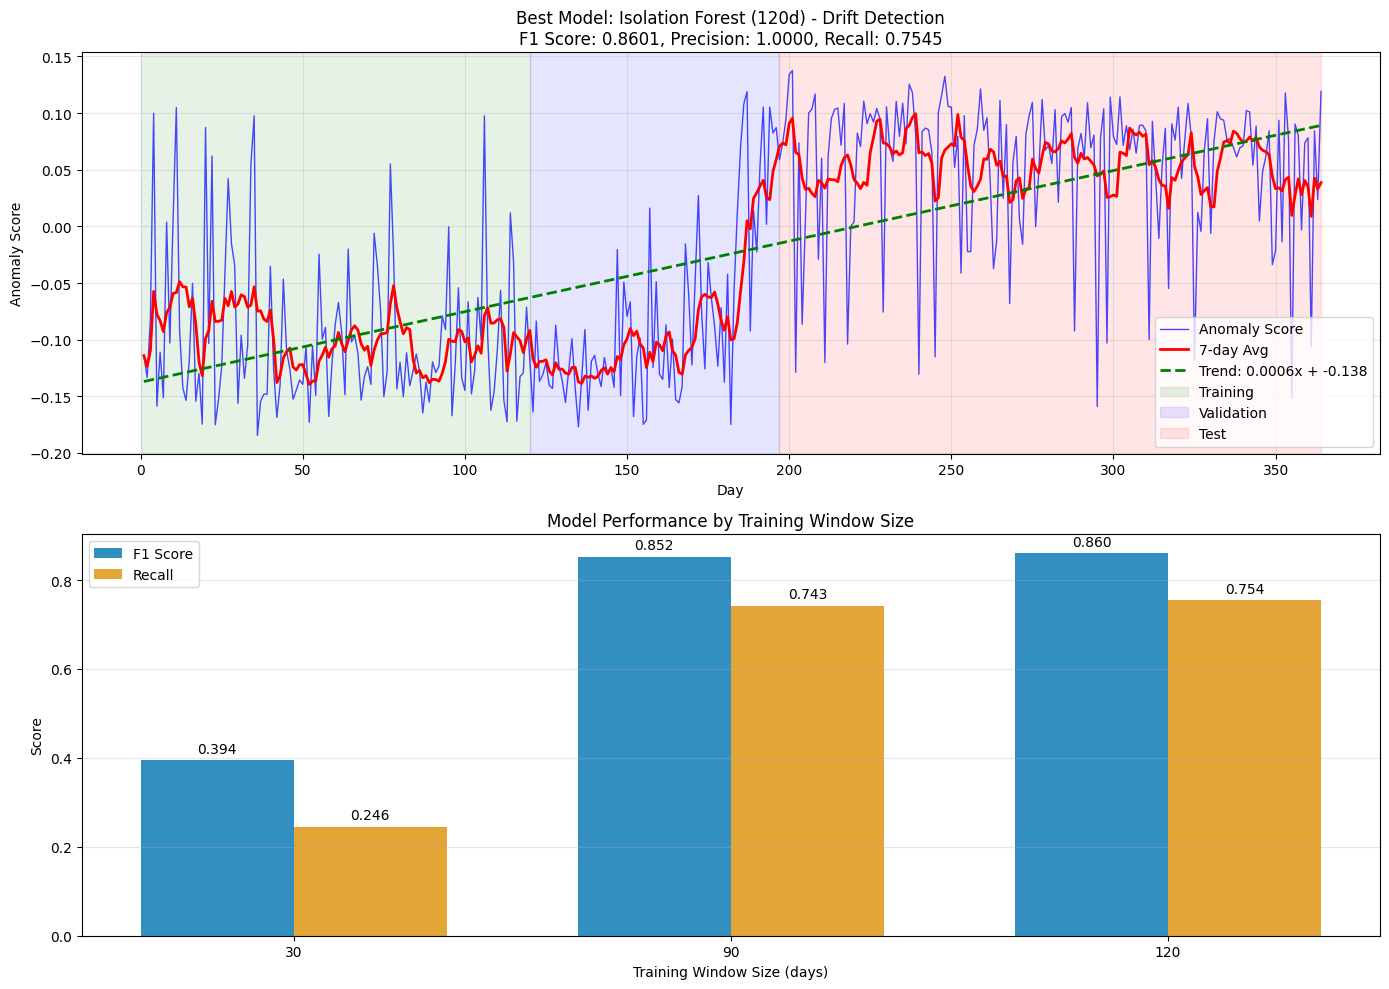

In [7]:
# MODEL TRAINING AND EVALUATION

# Initialize results storage
isolation_forest_results = []
best_model_info = None
best_f1 = -1
best_if_metrics = None           # store precision/recall of best run
best_if_train_mask = None        # store training mask of best run

# Isolation Forest
for window_size in training_windows:
    training_mask = select_training_days(window_size)
    if training_mask.sum() < 10:
        print(f"Skipping window size {window_size}: insufficient training data ({training_mask.sum()} samples)")
        continue

    features = create_features_for_model(training_mask)

    # Remove constant features based on the TRAINING WINDOW only
    constant_mask = features[training_mask].nunique(dropna=False) <= 1
    features = features.loc[:, ~constant_mask]

    # Scale features using training data only
    scaler = StandardScaler()
    X_train = scaler.fit_transform(features[training_mask])
    X_all = scaler.transform(features)

    # Adjust max_samples to avoid warnings
    n_samples = X_train.shape[0]
    max_samples_adjusted = min(256, n_samples)

    # Train Isolation Forest
    model = IsolationForest(
        n_estimators=200,
        max_samples=max_samples_adjusted,
        contamination=0.1,
        random_state=SEED,
        n_jobs=-1
    )

    model.fit(X_train)
    scores = -model.decision_function(X_all)

    # Determine optimal threshold
    threshold, validation_f1 = choose_threshold(
        scores, training_mask, validation_mask, use_validation_for_threshold, labels
    )

    # Evaluate on test set
    test_labels, test_scores = labels[test_mask], scores[test_mask]
    test_auc = roc_auc_score(test_labels, test_scores)
    test_ap = average_precision_score(test_labels, test_scores)

    test_predictions = (test_scores >= threshold).astype(int)

    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix(test_labels, test_predictions).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + fp + fn + tn)
    balanced_accuracy = (recall + (tn / (tn + fp))) / 2 if (tn + fp) > 0 else recall / 2

    # Store results
    result = {
        "training_days": window_size,
        "f1_score": f1,
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "auc": test_auc,
        "average_precision": test_ap,
        "threshold": threshold,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
        "scores": scores
    }

    isolation_forest_results.append(result)

    # Track best model (keep its metrics + training mask)
    if f1 > best_f1:
        best_f1 = f1
        best_model_info = (window_size, scores, model)
        best_if_metrics = {"precision": precision, "recall": recall}
        best_if_train_mask = training_mask.copy()

# SINGLE COMPREHENSIVE TABLE
print("\n" + "="*120)
print("ISOLATION FOREST PERFORMANCE SUMMARY")
print("="*120)
print(f"{'Training Days':<15} {'F1 Score':<10} {'Precision':<10} {'Recall':<10} {'Accuracy':<10} {'Balanced Acc':<12} {'AUC':<8} {'Avg Precision':<12}")
print("-"*120)

for result in isolation_forest_results:
    print(f"{result['training_days']:<15} {result['f1_score']:<10.4f} {result['precision']:<10.4f} "
          f"{result['recall']:<10.4f} {result['accuracy']:<10.4f} {result['balanced_accuracy']:<12.4f} "
          f"{result['auc']:<8.4f} {result['average_precision']:<12.4f}")

# Confusion matrix summary
print("\n" + "="*80)
print("CONFUSION MATRIX SUMMARY")
print("="*80)
print(f"{'Training Days':<15} {'TP':<6} {'FP':<6} {'FN':<6} {'TN':<6}")
print("-"*80)

for result in isolation_forest_results:
    total_samples = result['true_positives'] + result['false_positives'] + result['false_negatives'] + result['true_negatives']
    anomaly_ratio = (result['true_positives'] + result['false_negatives']) / total_samples
    print(f"{result['training_days']:<15} {result['true_positives']:<6} {result['false_positives']:<6} "
          f"{result['false_negatives']:<6} {result['true_negatives']:<6}")

# SINGLE GRAPH (Best Model Only)
if best_model_info:
    best_window, scores, model = best_model_info
    print(f"\n Generating visualization for best model: {best_window}d (F1 Score: {best_f1:.4f})")

    # Create the single comprehensive plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Drift Detection with Scores
    valid_mask = ~np.isnan(scores)
    days_valid = days[valid_mask]
    scores_valid = scores[valid_mask]

    # Raw scores
    ax1.plot(days_valid, scores_valid, 'b-', alpha=0.7, label='Anomaly Score', linewidth=1)

    # Smoothed scores
    smoothed_scores = pd.Series(scores_valid).rolling(window=7, min_periods=1).mean()
    ax1.plot(days_valid, smoothed_scores, 'r-', linewidth=2, label='7-day Avg')

    # Trend line
    if len(scores_valid) > 10:
        z = np.polyfit(days_valid, scores_valid, 1)
        p = np.poly1d(z)
        trend_line = p(days_valid)
        ax1.plot(days_valid, trend_line, 'g--', linewidth=2, label=f'Trend: {z[0]:.4f}x + {z[1]:.3f}')

    # Add regions using the BEST window's mask
    best_train_mask = best_if_train_mask if best_if_train_mask is not None else select_training_days(best_window)
    training_end = days[best_train_mask].max() if np.any(best_train_mask) else 0
    validation_end = days[validation_mask].max() if np.any(validation_mask) else 0

    ax1.axvspan(0, training_end, alpha=0.1, color='green', label='Training')
    ax1.axvspan(training_end, validation_end, alpha=0.1, color='blue', label='Validation')
    ax1.axvspan(validation_end, np.max(days_valid), alpha=0.1, color='red', label='Test')

    ax1.set_xlabel('Day')
    ax1.set_ylabel('Anomaly Score')
    ax1.set_title(
        f'Best Model: Isolation Forest ({best_window}d) - Drift Detection\n'
        f'F1 Score: {best_f1:.4f}, Precision: {best_if_metrics["precision"]:.4f}, '
        f'Recall: {best_if_metrics["recall"]:.4f}'
    )
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Performance Comparison
    window_sizes = [r['training_days'] for r in isolation_forest_results]
    f1_scores = [r['f1_score'] for r in isolation_forest_results]
    recall_scores = [r['recall'] for r in isolation_forest_results]

    x_pos = np.arange(len(window_sizes))
    width = 0.35

    ax2.bar(x_pos - width/2, f1_scores, width, label='F1 Score', alpha=0.8)
    ax2.bar(x_pos + width/2, recall_scores, width, label='Recall', alpha=0.8)

    ax2.set_xlabel('Training Window Size (days)')
    ax2.set_ylabel('Score')
    ax2.set_title('Model Performance by Training Window Size')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(window_sizes)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for i, v in enumerate(f1_scores):
        ax2.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    for i, v in enumerate(recall_scores):
        ax2.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()
else:
    print("No valid models were trained.")



ONE-CLASS SVM PERFORMANCE SUMMARY
Training Days   F1 Score   Precision  Recall     Accuracy   Balanced Acc AUC      Avg Precision nu      
------------------------------------------------------------------------------------------------------------------------
30              0.9430     1.0000     0.8922     0.9086     0.9461       0.9653   0.9942       0.0300  
90              0.9121     1.0000     0.8383     0.8629     0.9192       0.9433   0.9904       0.0300  
120             0.9156     1.0000     0.8443     0.8680     0.9222       0.9463   0.9910       0.0300  

ONE-CLASS SVM CONFUSION MATRIX SUMMARY
Training Days   TP     FP     FN     TN    
--------------------------------------------------------------------------------
30              149    0      18     30    
90              140    0      27     30    
120             141    0      26     30    

Generating visualization for best SVM model: 30d (F1 Score: 0.9430)


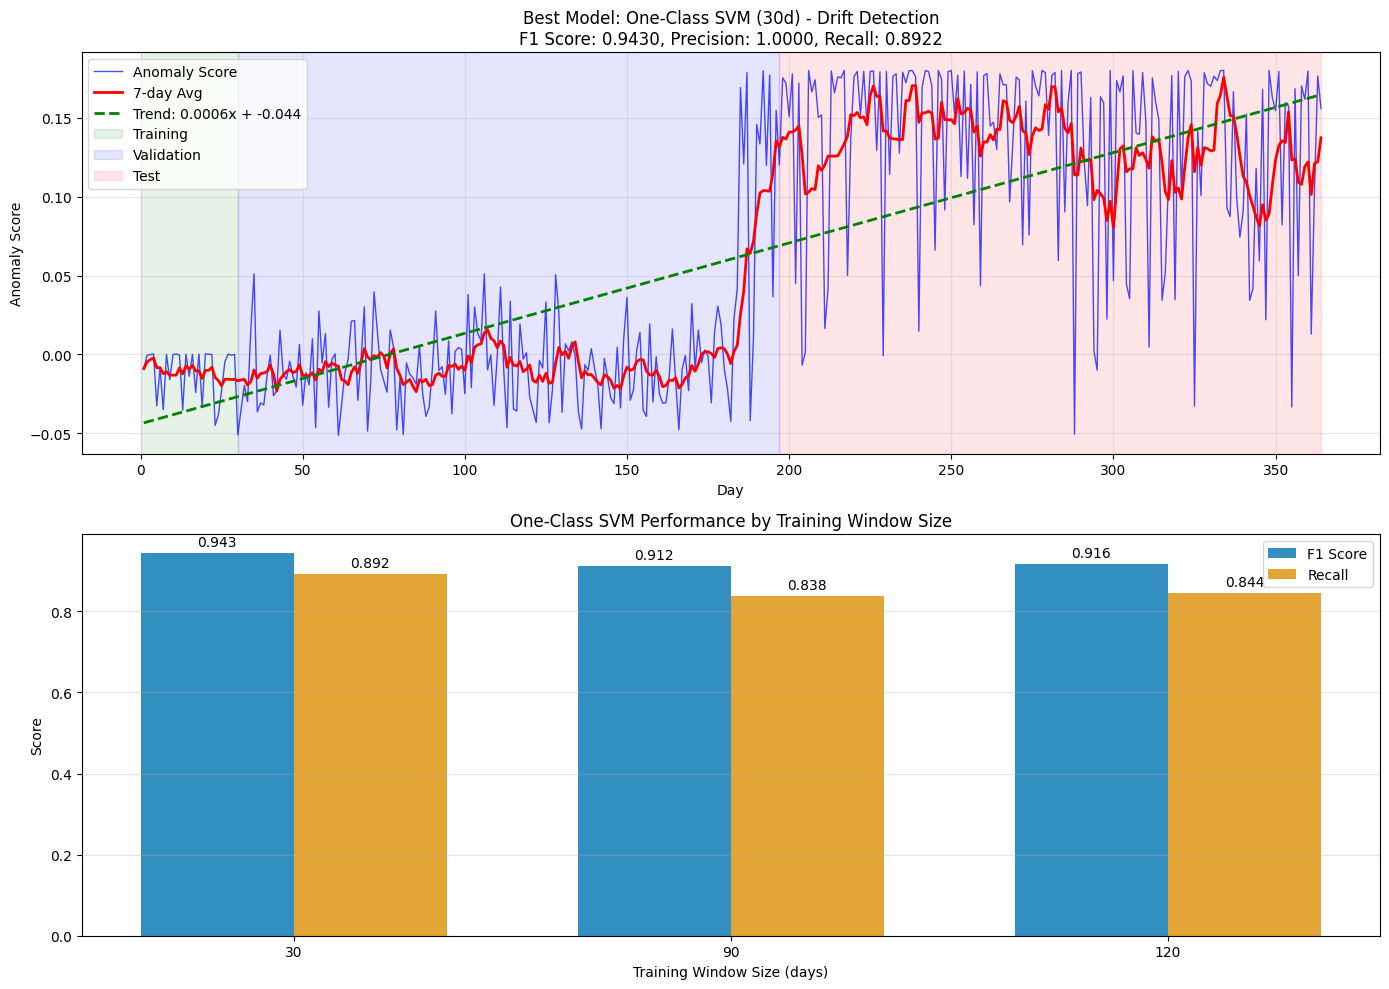

In [8]:
# ONE-CLASS SVM TRAINING AND EVALUATION

one_class_svm_results = []
best_svm_info = None
best_svm_f1 = -1
best_svm_metrics = None
best_svm_train_mask = None

# One-Class SVM Training
for window_size in training_windows:
    training_mask = select_training_days(window_size)
    if training_mask.sum() < 10:
        continue

    # Features (drop constants on training period)
    features = create_features_for_model(training_mask)
    constant_mask = features[training_mask].nunique(dropna=False) <= 1
    features = features.loc[:, ~constant_mask]

    # Scale using training data only
    scaler = StandardScaler()
    X_train = scaler.fit_transform(features[training_mask])
    X_all   = scaler.transform(features)

    # Determine appropriate nu parameter
    nu_value = calculate_svm_nu(len(X_train))

    # Train One-Class SVM
    model = OneClassSVM(kernel='rbf', gamma='scale', nu=nu_value)
    model.fit(X_train)

    # Scores (higher = more anomalous)
    scores = -model.decision_function(X_all).ravel()

    # Threshold (validation or quantile)
    threshold, validation_f1 = choose_threshold(
        scores, training_mask, validation_mask, use_validation_for_threshold, labels
    )

    # Evaluate on test set
    test_labels = labels[test_mask]
    test_scores = scores[test_mask]
    test_auc = roc_auc_score(test_labels, test_scores)
    test_ap  = average_precision_score(test_labels, test_scores)

    test_predictions = (test_scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(test_labels, test_predictions).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy = (tp + tn) / (tp + fp + fn + tn)
    balanced_accuracy = (recall + (tn / (tn + fp))) / 2 if (tn + fp) > 0 else recall / 2

    # Store results
    result = {
        "training_days": window_size,
        "nu": nu_value,
        "f1_score": f1,
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "auc": test_auc,
        "average_precision": test_ap,
        "threshold": threshold,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
        "scores": scores
    }
    one_class_svm_results.append(result)

    # Track best model
    if f1 > best_svm_f1:
        best_svm_f1 = f1
        best_svm_info = (window_size, scores, model)
        best_svm_metrics = {"precision": precision, "recall": recall}
        best_svm_train_mask = training_mask.copy()

# SUMMARY TABLES
print("\n" + "="*120)
print("ONE-CLASS SVM PERFORMANCE SUMMARY")
print("="*120)
print(f"{'Training Days':<15} {'F1 Score':<10} {'Precision':<10} {'Recall':<10} "
      f"{'Accuracy':<10} {'Balanced Acc':<12} {'AUC':<8} {'Avg Precision':<12} {'nu':<8}")
print("-"*120)
for r in one_class_svm_results:
    print(f"{r['training_days']:<15} {r['f1_score']:<10.4f} {r['precision']:<10.4f} "
          f"{r['recall']:<10.4f} {r['accuracy']:<10.4f} {r['balanced_accuracy']:<12.4f} "
          f"{r['auc']:<8.4f} {r['average_precision']:<12.4f} {r['nu']:<8.4f}")

print("\n" + "="*80)
print("ONE-CLASS SVM CONFUSION MATRIX SUMMARY")
print("="*80)
print(f"{'Training Days':<15} {'TP':<6} {'FP':<6} {'FN':<6} {'TN':<6}")
print("-"*80)
for r in one_class_svm_results:
    print(f"{r['training_days']:<15} {r['true_positives']:<6} {r['false_positives']:<6} "
          f"{r['false_negatives']:<6} {r['true_negatives']:<6}")

# SINGLE GRAPH (Best Only)
if best_svm_info:
    window_size, scores, _ = best_svm_info
    print(f"\nGenerating visualization for best SVM model: {window_size}d (F1 Score: {best_svm_f1:.4f})")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    valid = np.isfinite(scores)
    days_valid   = days[valid]
    scores_valid = scores[valid]

    # Raw + smoothed
    ax1.plot(days_valid, scores_valid, 'b-', alpha=0.7, label='Anomaly Score', linewidth=1)
    smoothed = pd.Series(scores_valid).rolling(window=7, min_periods=1).mean().to_numpy()
    ax1.plot(days_valid, smoothed, 'r-', linewidth=2, label='7-day Avg')

    # NaN-safe trend
    if len(scores_valid) > 10:
        finite = np.isfinite(scores_valid)
        if finite.sum() > 1:
            z = np.polyfit(days_valid[finite], scores_valid[finite], 1)
            ax1.plot(days_valid[finite], np.polyval(z, days_valid[finite]),
                     'g--', linewidth=2, label=f'Trend: {z[0]:.4f}x + {z[1]:.3f}')

    # Regions: use BEST window's training mask
    if best_svm_train_mask is not None and np.any(best_svm_train_mask):
        training_end = days[best_svm_train_mask].max()
    else:
        training_end = 0
    validation_end = days[validation_mask].max() if np.any(validation_mask) else 0

    ax1.axvspan(0, training_end, alpha=0.1, color='green', label='Training')
    ax1.axvspan(training_end, validation_end, alpha=0.1, color='blue',  label='Validation')
    ax1.axvspan(validation_end, days_valid.max(), alpha=0.1, color='red', label='Test')

    ax1.set_xlabel('Day')
    ax1.set_ylabel('Anomaly Score')
    ax1.set_title(
        f'Best Model: One-Class SVM ({window_size}d) - Drift Detection\n'
        f'F1 Score: {best_svm_f1:.4f}, Precision: {best_svm_metrics["precision"]:.4f}, '
        f'Recall: {best_svm_metrics["recall"]:.4f}'
    )
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Bar chart: performance vs window
    window_sizes  = [r['training_days'] for r in one_class_svm_results]
    f1_scores     = [r['f1_score'] for r in one_class_svm_results]
    recall_scores = [r['recall'] for r in one_class_svm_results]

    x = np.arange(len(window_sizes))
    w = 0.35
    ax2.bar(x - w/2, f1_scores,    w, label='F1 Score', alpha=0.8)
    ax2.bar(x + w/2, recall_scores,w, label='Recall',   alpha=0.8)
    ax2.set_xlabel('Training Window Size (days)')
    ax2.set_ylabel('Score')
    ax2.set_title('One-Class SVM Performance by Training Window Size')
    ax2.set_xticks(x)
    ax2.set_xticklabels(window_sizes)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(f1_scores):
        ax2.text(i - w/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    for i, v in enumerate(recall_scores):
        ax2.text(i + w/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()
else:
    print("No valid SVM models were trained.")



LSTM PERFORMANCE SUMMARY
Training Days   F1 Score   Precision  Recall     Accuracy   Balanced Acc AUC      Avg Precision
------------------------------------------------------------------------------------------------------------------------
30              0.9363     1.0000     0.8802     0.8985     0.9401       0.9611   0.9935      
90              0.9206     0.9797     0.8683     0.8731     0.8841       0.9337   0.9886      
120             0.9177     0.9732     0.8683     0.8680     0.8675       0.9391   0.9893      

LSTM CONFUSION MATRIX SUMMARY
Training Days   TP     FP     FN     TN    
--------------------------------------------------------------------------------
30              147    0      20     30    
90              145    3      22     27    
120             145    4      22     26    

 Generating visualization for best LSTM model: 30d (F1 Score: 0.9363)


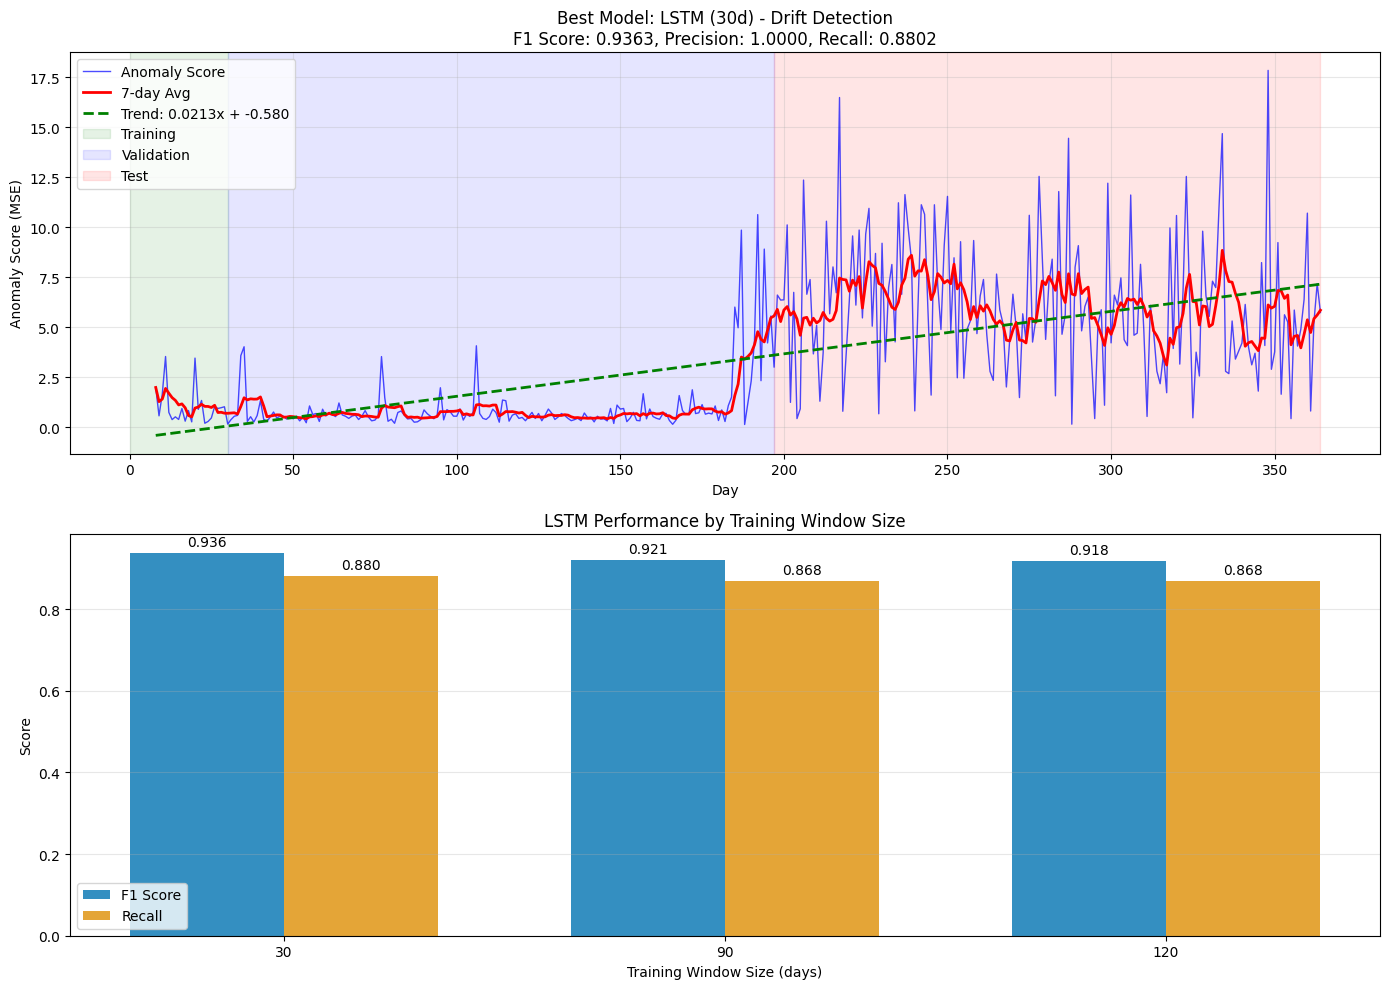

In [9]:
# LSTM TRAINING AND EVALUATION

def create_sequences(feature_df, valid_days_mask, sequence_length):
    """
    Create sequences for LSTM training/prediction
    """
    feature_values = feature_df.values
    target_indices = np.where(valid_days_mask)[0]

    sequences, targets, indices = [], [], []
    for idx in target_indices:
        start_idx = idx - sequence_length
        if start_idx < 0:
            continue

        sequences.append(feature_values[start_idx:idx])
        targets.append(feature_values[idx])
        indices.append(idx)

    if not sequences:
        return (np.empty((0, sequence_length, feature_values.shape[1])),
                np.empty((0, feature_values.shape[1])),
                np.array([], dtype=int))

    return np.stack(sequences), np.stack(targets), np.array(indices, dtype=int)

def build_lstm_model(input_features, seq_length):
    """Build and compile LSTM model for forecasting"""
    inputs = layers.Input(shape=(seq_length, input_features))
    x = layers.LSTM(64, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(16)(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(input_features)(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model

# Initialize results storage
lstm_results = []
best_lstm_info = None
best_lstm_f1 = -1
best_lstm_metrics = None
best_lstm_train_mask = None

# LSTM Training
for window_size in training_windows:
    training_mask = select_training_days(window_size)
    if training_mask.sum() < sequence_length + 5:
        continue

    features = create_features_for_model(training_mask)

    # Remove constant features based on the TRAINING WINDOW only
    constant_mask = features[training_mask].nunique(dropna=False) <= 1
    features = features.loc[:, ~constant_mask]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(features[training_mask])
    X_all = scaler.transform(features)
    X_all_df = pd.DataFrame(X_all, index=features.index, columns=features.columns)

    # Create sequences for training
    X_seq_train, Y_train, train_indices = create_sequences(
        X_all_df, training_mask, sequence_length
    )

    if len(X_seq_train) < 20:
        continue

    # Split training data for validation
    n_train = len(X_seq_train)
    val_split = max(1, int(np.floor((1.0 - validation_fraction) * n_train)))

    X_tr, Y_tr = X_seq_train[:val_split], Y_train[:val_split]
    X_val, Y_val = X_seq_train[val_split:], Y_train[val_split:]

    # Build and train model
    model = build_lstm_model(X_seq_train.shape[2], sequence_length)
    early_stopping = callbacks.EarlyStopping(
        monitor="val_loss", patience=lstm_early_stopping, restore_best_weights=True
    )

    try:
        history = model.fit(
            X_tr, Y_tr,
            validation_data=(X_val, Y_val),
            epochs=lstm_epochs,
            batch_size=lstm_batch_size,
            callbacks=[early_stopping],
            verbose=0
        )

        # Generate predictions for all possible sequences
        X_seq_all, Y_all, all_indices = create_sequences(
            X_all_df, np.ones_like(days, bool), sequence_length
        )

        Y_pred = model.predict(X_seq_all, verbose=0)
        mse_scores = np.mean(np.square(Y_all - Y_pred), axis=1)

        # Create full score array (NaN for days without enough history)
        scores = np.full_like(days, np.nan, dtype=float)
        scores[all_indices] = mse_scores

    finally:
        tf.keras.backend.clear_session()
        gc.collect()

    # Determine optimal threshold
    threshold, validation_f1 = choose_threshold(
        scores, training_mask, validation_mask, use_validation_for_threshold, labels
    )

    # Evaluate on test set
    test_scores_mask = test_mask & ~np.isnan(scores)
    test_labels, test_scores = labels[test_scores_mask], scores[test_scores_mask]

    test_auc = roc_auc_score(test_labels, test_scores)
    test_ap = average_precision_score(test_labels, test_scores)

    test_predictions = (test_scores >= threshold).astype(int)

    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix(test_labels, test_predictions).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + fp + fn + tn)
    balanced_accuracy = (recall + (tn / (tn + fp))) / 2 if (tn + fp) > 0 else recall / 2

    # Store results
    result = {
        "training_days": window_size,
        "f1_score": f1,
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "auc": test_auc,
        "average_precision": test_ap,
        "threshold": threshold,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
        "scores": scores
    }

    lstm_results.append(result)

    # Track best model and keep its metrics + training mask
    if f1 > best_lstm_f1:
        best_lstm_f1 = f1
        best_lstm_info = (window_size, scores)
        best_lstm_metrics = {"precision": precision, "recall": recall}
        best_lstm_train_mask = training_mask.copy()

# SINGLE COMPREHENSIVE TABLE
print("\n" + "="*120)
print("LSTM PERFORMANCE SUMMARY")
print("="*120)
print(f"{'Training Days':<15} {'F1 Score':<10} {'Precision':<10} {'Recall':<10} {'Accuracy':<10} {'Balanced Acc':<12} {'AUC':<8} {'Avg Precision':<12}")
print("-"*120)

for result in lstm_results:
    print(f"{result['training_days']:<15} {result['f1_score']:<10.4f} {result['precision']:<10.4f} "
          f"{result['recall']:<10.4f} {result['accuracy']:<10.4f} {result['balanced_accuracy']:<12.4f} "
          f"{result['auc']:<8.4f} {result['average_precision']:<12.4f}")

# Confusion matrix summary
print("\n" + "="*80)
print("LSTM CONFUSION MATRIX SUMMARY")
print("="*80)
print(f"{'Training Days':<15} {'TP':<6} {'FP':<6} {'FN':<6} {'TN':<6}")
print("-"*80)

for result in lstm_results:
    total_samples = result['true_positives'] + result['false_positives'] + result['false_negatives'] + result['true_negatives']
    anomaly_ratio = (result['true_positives'] + result['false_negatives']) / total_samples
    print(f"{result['training_days']:<15} {result['true_positives']:<6} {result['false_positives']:<6} "
          f"{result['false_negatives']:<6} {result['true_negatives']:<6}")

# SINGLE GRAPH (Best Model Only)
if best_lstm_info:
    window_size, scores = best_lstm_info
    print(f"\n Generating visualization for best LSTM model: {window_size}d (F1 Score: {best_lstm_f1:.4f})")

    # Create the single comprehensive plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Drift Detection with Scores
    valid_mask = ~np.isnan(scores)
    days_valid = days[valid_mask]
    scores_valid = scores[valid_mask]

    # Raw scores
    ax1.plot(days_valid, scores_valid, 'b-', alpha=0.7, label='Anomaly Score', linewidth=1)

    # Smoothed scores
    smoothed_scores = pd.Series(scores_valid).rolling(window=7, min_periods=1).mean()
    ax1.plot(days_valid, smoothed_scores, 'r-', linewidth=2, label='7-day Avg')

    # Trend line
    if len(scores_valid) > 10:
        z = np.polyfit(days_valid, scores_valid, 1)
        p = np.poly1d(z)
        trend_line = p(days_valid)
        ax1.plot(days_valid, trend_line, 'g--', linewidth=2, label=f'Trend: {z[0]:.4f}x + {z[1]:.3f}')

    # Add regions using the BEST window's mask
    best_train_mask = best_lstm_train_mask if best_lstm_train_mask is not None else select_training_days(window_size)
    training_end = np.max(days[best_train_mask]) if np.any(best_train_mask) else 0
    validation_end = np.max(days[validation_mask]) if np.any(validation_mask) else 0

    ax1.axvspan(0, training_end, alpha=0.1, color='green', label='Training')
    ax1.axvspan(training_end, validation_end, alpha=0.1, color='blue', label='Validation')
    ax1.axvspan(validation_end, np.max(days_valid), alpha=0.1, color='red', label='Test')

    ax1.set_xlabel('Day')
    ax1.set_ylabel('Anomaly Score (MSE)')
    ax1.set_title(
        f'Best Model: LSTM ({window_size}d) - Drift Detection\n'
        f'F1 Score: {best_lstm_f1:.4f}, Precision: {best_lstm_metrics["precision"]:.4f}, '
        f'Recall: {best_lstm_metrics["recall"]:.4f}'
    )
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Performance Comparison
    window_sizes = [r['training_days'] for r in lstm_results]
    f1_scores = [r['f1_score'] for r in lstm_results]
    recall_scores = [r['recall'] for r in lstm_results]

    x_pos = np.arange(len(window_sizes))
    width = 0.35

    ax2.bar(x_pos - width/2, f1_scores, width, label='F1 Score', alpha=0.8)
    ax2.bar(x_pos + width/2, recall_scores, width, label='Recall', alpha=0.8)

    ax2.set_xlabel('Training Window Size (days)')
    ax2.set_ylabel('Score')
    ax2.set_title('LSTM Performance by Training Window Size')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(window_sizes)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for i, v in enumerate(f1_scores):
        ax2.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    for i, v in enumerate(recall_scores):
        ax2.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

else:
    print("No valid LSTM models were trained.")



AUTOENCODER PERFORMANCE SUMMARY
Training Days   F1 Score   Precision  Recall     Accuracy   Balanced Acc AUC      Avg Precision
------------------------------------------------------------------------------------------------------------------------
30              0.8977     1.0000     0.8144     0.8426     0.9072       0.9505   0.9916      
90              0.9506     0.9809     0.9222     0.9188     0.9111       0.9653   0.9942      
120             0.9446     0.9205     0.9701     0.9036     0.7517       0.9613   0.9934      

AUTOENCODER CONFUSION MATRIX SUMMARY
Training Days   TP     FP     FN     TN    
--------------------------------------------------------------------------------
30              136    0      31     30    
90              154    3      13     27    
120             162    14     5      16    

 Generating visualization for best Autoencoder model: 90d (F1 Score: 0.9506)


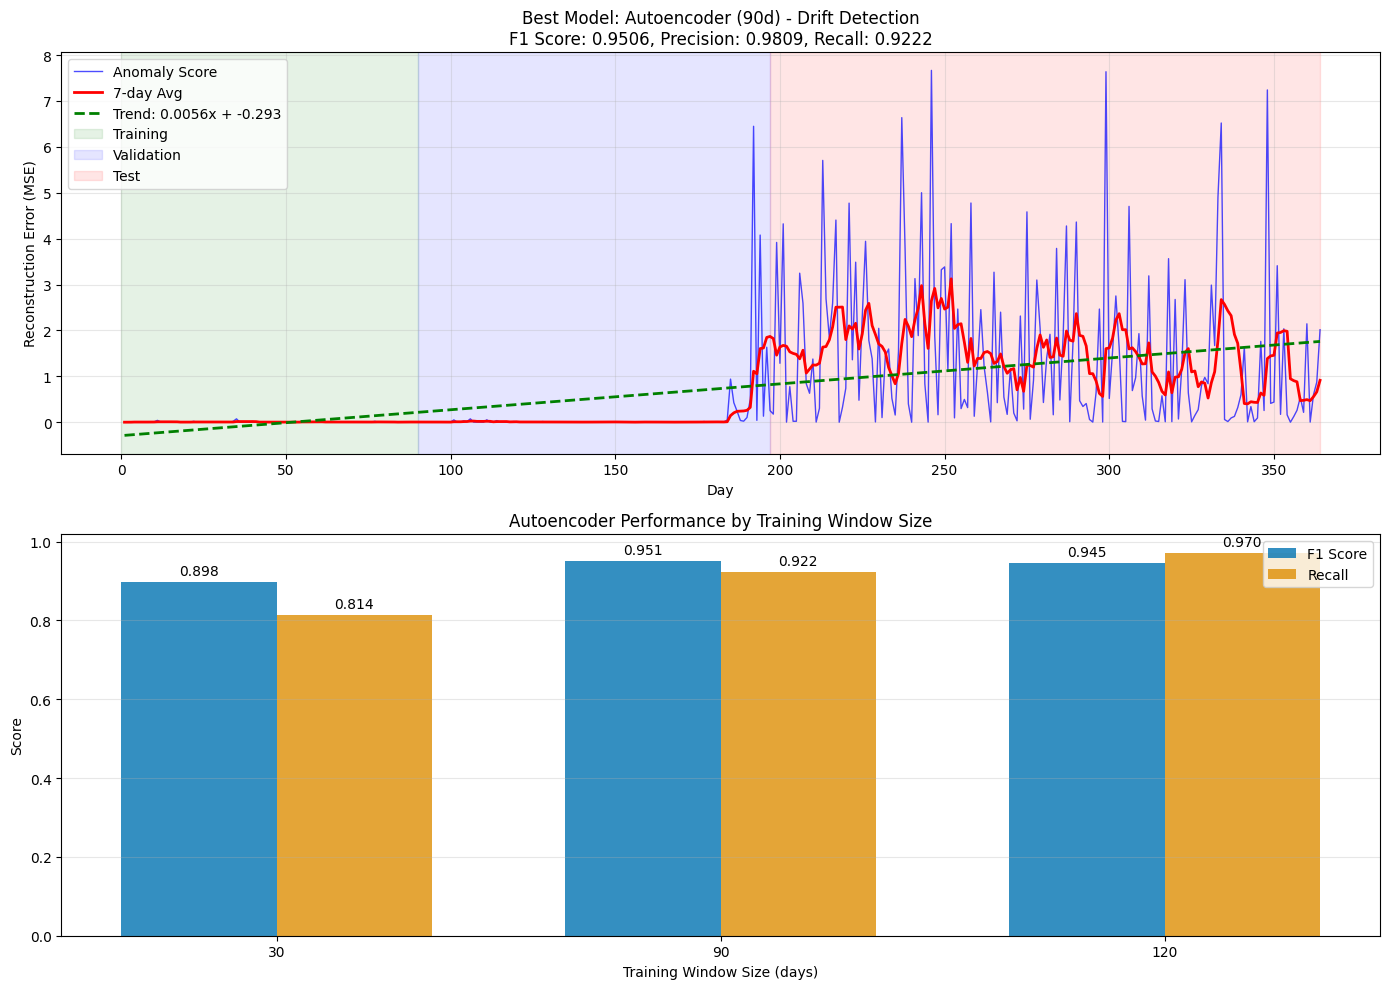

In [10]:
# AUTOENCODER TRAINING AND EVALUATION

def build_autoencoder_model(input_features):

    bottleneck_size = max(8, input_features // autoencoder_bottleneck_factor)

    inputs = layers.Input(shape=(input_features,))
    x = layers.Dense(autoencoder_hidden_units[0], activation="relu")(inputs)
    x = layers.Dense(autoencoder_hidden_units[1], activation="relu")(x)
    encoded = layers.Dense(bottleneck_size, activation="relu")(x)

    x = layers.Dense(autoencoder_hidden_units[1], activation="relu")(encoded)
    x = layers.Dense(autoencoder_hidden_units[0], activation="relu")(x)
    decoded = layers.Dense(input_features)(x)

    model = tf.keras.Model(inputs, decoded)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(autoencoder_learning_rate),
        loss="mse"
    )
    return model

# Initialize results storage
autoencoder_results = []
best_autoencoder_info = None
best_autoencoder_f1 = -1
best_autoencoder_metrics = None          # store precision/recall of best run
best_autoencoder_train_mask = None       # store training mask of best run


# Autoencoder Training
for window_size in training_windows:
    training_mask = select_training_days(window_size)
    if training_mask.sum() < 10:
        continue

    features = create_features_for_model(training_mask)

    # Remove constant features based on the TRAINING WINDOW only
    constant_mask = features[training_mask].nunique(dropna=False) <= 1
    features = features.loc[:, ~constant_mask]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(features[training_mask])
    X_all = scaler.transform(features)

    # Split training data for validation
    n_train = len(X_train)
    val_split = max(1, int(np.floor((1.0 - validation_fraction) * n_train)))

    X_tr, X_val = X_train[:val_split], X_train[val_split:]

    # Build and train model
    model = build_autoencoder_model(X_train.shape[1])
    early_stopping = callbacks.EarlyStopping(
        monitor="val_loss", patience=12, restore_best_weights=True
    )

    try:
        history = model.fit(
            X_tr, X_tr,
            validation_data=(X_val, X_val),
            epochs=autoencoder_epochs,
            batch_size=32,  # Using fixed batch size
            callbacks=[early_stopping],
            verbose=0
        )

        # Generate reconstructions and calculate reconstruction error
        X_reconstructed = model.predict(X_all, verbose=0)
        scores = np.mean(np.square(X_all - X_reconstructed), axis=1)

    finally:
        tf.keras.backend.clear_session()
        gc.collect()

    # Determine optimal threshold
    threshold, validation_f1 = choose_threshold(
        scores, training_mask, validation_mask, use_validation_for_threshold, labels
    )

    # Evaluate on test set
    test_labels, test_scores = labels[test_mask], scores[test_mask]
    test_auc = roc_auc_score(test_labels, test_scores)
    test_ap = average_precision_score(test_labels, test_scores)

    test_predictions = (test_scores >= threshold).astype(int)

    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix(test_labels, test_predictions).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + fp + fn + tn)
    balanced_accuracy = (recall + (tn / (tn + fp))) / 2 if (tn + fp) > 0 else recall / 2

    # Store results
    result = {
        "training_days": window_size,
        "f1_score": f1,
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "auc": test_auc,
        "average_precision": test_ap,
        "threshold": threshold,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
        "scores": scores
    }

    autoencoder_results.append(result)

    # Track best model (and keep its metrics + training mask)
    if f1 > best_autoencoder_f1:
        best_autoencoder_f1 = f1
        best_autoencoder_info = (window_size, scores)
        best_autoencoder_metrics = {"precision": precision, "recall": recall}
        best_autoencoder_train_mask = training_mask.copy()

# SINGLE COMPREHENSIVE TABLE
print("\n" + "="*120)
print("AUTOENCODER PERFORMANCE SUMMARY")
print("="*120)
print(f"{'Training Days':<15} {'F1 Score':<10} {'Precision':<10} {'Recall':<10} {'Accuracy':<10} {'Balanced Acc':<12} {'AUC':<8} {'Avg Precision':<12}")
print("-"*120)

for result in autoencoder_results:
    print(f"{result['training_days']:<15} {result['f1_score']:<10.4f} {result['precision']:<10.4f} "
          f"{result['recall']:<10.4f} {result['accuracy']:<10.4f} {result['balanced_accuracy']:<12.4f} "
          f"{result['auc']:<8.4f} {result['average_precision']:<12.4f}")

# Confusion matrix summary
print("\n" + "="*80)
print("AUTOENCODER CONFUSION MATRIX SUMMARY")
print("="*80)
print(f"{'Training Days':<15} {'TP':<6} {'FP':<6} {'FN':<6} {'TN':<6}")
print("-"*80)

for result in autoencoder_results:
    total_samples = result['true_positives'] + result['false_positives'] + result['false_negatives'] + result['true_negatives']
    anomaly_ratio = (result['true_positives'] + result['false_negatives']) / total_samples
    print(f"{result['training_days']:<15} {result['true_positives']:<6} {result['false_positives']:<6} "
          f"{result['false_negatives']:<6} {result['true_negatives']:<6}")

# SINGLE GRAPH (Best Model Only)
if best_autoencoder_info:
    window_size, scores = best_autoencoder_info
    print(f"\n Generating visualization for best Autoencoder model: {window_size}d (F1 Score: {best_autoencoder_f1:.4f})")

    # Create the single comprehensive plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Plot 1: Drift Detection with Scores
    valid_mask = ~np.isnan(scores)
    days_valid = days[valid_mask]
    scores_valid = scores[valid_mask]

    # Raw scores
    ax1.plot(days_valid, scores_valid, 'b-', alpha=0.7, label='Anomaly Score', linewidth=1)

    # Smoothed scores
    smoothed_scores = pd.Series(scores_valid).rolling(window=7, min_periods=1).mean()
    ax1.plot(days_valid, smoothed_scores, 'r-', linewidth=2, label='7-day Avg')

    # Trend line
    if len(scores_valid) > 10:
        z = np.polyfit(days_valid, scores_valid, 1)
        p = np.poly1d(z)
        trend_line = p(days_valid)
        ax1.plot(days_valid, trend_line, 'g--', linewidth=2, label=f'Trend: {z[0]:.4f}x + {z[1]:.3f}')

    # Add regions using the BEST window's mask
    best_train_mask = best_autoencoder_train_mask if best_autoencoder_train_mask is not None else select_training_days(window_size)
    training_end = np.max(days[best_train_mask]) if np.any(best_train_mask) else 0
    validation_end = np.max(days[validation_mask]) if np.any(validation_mask) else 0

    ax1.axvspan(0, training_end, alpha=0.1, color='green', label='Training')
    ax1.axvspan(training_end, validation_end, alpha=0.1, color='blue', label='Validation')
    ax1.axvspan(validation_end, np.max(days_valid), alpha=0.1, color='red', label='Test')

    ax1.set_xlabel('Day')
    ax1.set_ylabel('Reconstruction Error (MSE)')
    ax1.set_title(
        f'Best Model: Autoencoder ({window_size}d) - Drift Detection\n'
        f'F1 Score: {best_autoencoder_f1:.4f}, Precision: {best_autoencoder_metrics["precision"]:.4f}, '
        f'Recall: {best_autoencoder_metrics["recall"]:.4f}'
    )
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Performance Comparison
    window_sizes = [r['training_days'] for r in autoencoder_results]
    f1_scores = [r['f1_score'] for r in autoencoder_results]
    recall_scores = [r['recall'] for r in autoencoder_results]

    x_pos = np.arange(len(window_sizes))
    width = 0.35

    ax2.bar(x_pos - width/2, f1_scores, width, label='F1 Score', alpha=0.8)
    ax2.bar(x_pos + width/2, recall_scores, width, label='Recall', alpha=0.8)

    ax2.set_xlabel('Training Window Size (days)')
    ax2.set_ylabel('Score')
    ax2.set_title('Autoencoder Performance by Training Window Size')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(window_sizes)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for i, v in enumerate(f1_scores):
        ax2.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    for i, v in enumerate(recall_scores):
        ax2.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

else:
    print("No valid Autoencoder models were trained.")


In [11]:
# RESULTS ANALYSIS AND VISUALIZATION

if_results_df = pd.DataFrame(isolation_forest_results).sort_values("training_days")
svm_results_df = pd.DataFrame(one_class_svm_results).sort_values("training_days")
lstm_results_df = pd.DataFrame(lstm_results).sort_values("training_days")
ae_results_df = pd.DataFrame(autoencoder_results).sort_values("training_days")

# CLEAN RESULTS SUMMARY
print("\n" + "="*80)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*80)
print(f"{'Model':<20} {'Best F1':<8} {'Precision':<10} {'Recall':<8} {'Anomalies Caught':<16} {'FP':<6}")
print("-"*80)

# Get best model from each type
best_models = []
for model_name, df in [("Isolation Forest", if_results_df),
                       ("One-Class SVM", svm_results_df),
                       ("LSTM", lstm_results_df),
                       ("Autoencoder", ae_results_df)]:
    if not df.empty:
        best_idx = df['f1_score'].idxmax()
        best_model = df.loc[best_idx]
        anomalies_caught = f"{best_model['true_positives']}/{best_model['true_positives'] + best_model['false_negatives']}"
        best_models.append((model_name, best_model, anomalies_caught))

# Sort by F1 score descending
best_models.sort(key=lambda x: x[1]['f1_score'], reverse=True)

for model_name, best_model, anomalies_caught in best_models:
    print(f"{model_name:<20} {best_model['f1_score']:<8.4f} {best_model['precision']:<10.4f} "
          f"{best_model['recall']:<8.4f} {anomalies_caught:<16} {best_model['false_positives']:<6}")


# DETAILED RESULTS
print("\n" + "="*80)
print("="*80)

print("\n=== Isolation Forest ===")
if not if_results_df.empty:
    print(if_results_df[['training_days', 'f1_score', 'precision', 'recall', 'true_positives', 'false_positives']].to_string(index=False))

print("\n=== One-Class SVM ===")
if not svm_results_df.empty:
    print(svm_results_df[['training_days', 'f1_score', 'precision', 'recall', 'true_positives', 'false_positives']].to_string(index=False))

print("\n=== LSTM ===")
if not lstm_results_df.empty:
    print(lstm_results_df[['training_days', 'f1_score', 'precision', 'recall', 'true_positives', 'false_positives']].to_string(index=False))

print("\n=== Autoencoder ===")
if not ae_results_df.empty:
    print(ae_results_df[['training_days', 'f1_score', 'precision', 'recall', 'true_positives', 'false_positives']].to_string(index=False))



FINAL MODEL COMPARISON SUMMARY
Model                Best F1  Precision  Recall   Anomalies Caught FP    
--------------------------------------------------------------------------------
Autoencoder          0.9506   0.9809     0.9222   154/167          3     
One-Class SVM        0.9430   1.0000     0.8922   149/167          0     
LSTM                 0.9363   1.0000     0.8802   147/167          0     
Isolation Forest     0.8601   1.0000     0.7545   126/167          0     


=== Isolation Forest ===
 training_days  f1_score  precision   recall  true_positives  false_positives
            30  0.394231        1.0 0.245509              41                0
            90  0.852234        1.0 0.742515             124                0
           120  0.860068        1.0 0.754491             126                0

=== One-Class SVM ===
 training_days  f1_score  precision   recall  true_positives  false_positives
            30  0.943038        1.0 0.892216             149                0


FINAL MODEL COMPARISON - BEST PERFORMING CONFIGURATIONS
Model                Days   F1       Precision  Recall     Caught       FP     AUC      Bal Acc 
------------------------------------------------------------------------------------------
Autoencoder          90     0.9506   0.9809     0.9222     154/167      3      0.9653   0.9111  
One-Class SVM        30     0.9430   1.0000     0.8922     149/167      0      0.9653   0.9461  
LSTM                 30     0.9363   1.0000     0.8802     147/167      0      0.9611   0.9401  
Isolation Forest     120    0.8601   1.0000     0.7545     126/167      0      0.9389   0.8772  

KEY INSIGHTS

 Best Overall: Autoencoder (90d)
   F1: 0.9506, Precision: 0.9809, Recall: 0.9222

 Perfect Precision: One-Class SVM, LSTM, Isolation Forest
Highest Recall: Autoencoder (0.9222)


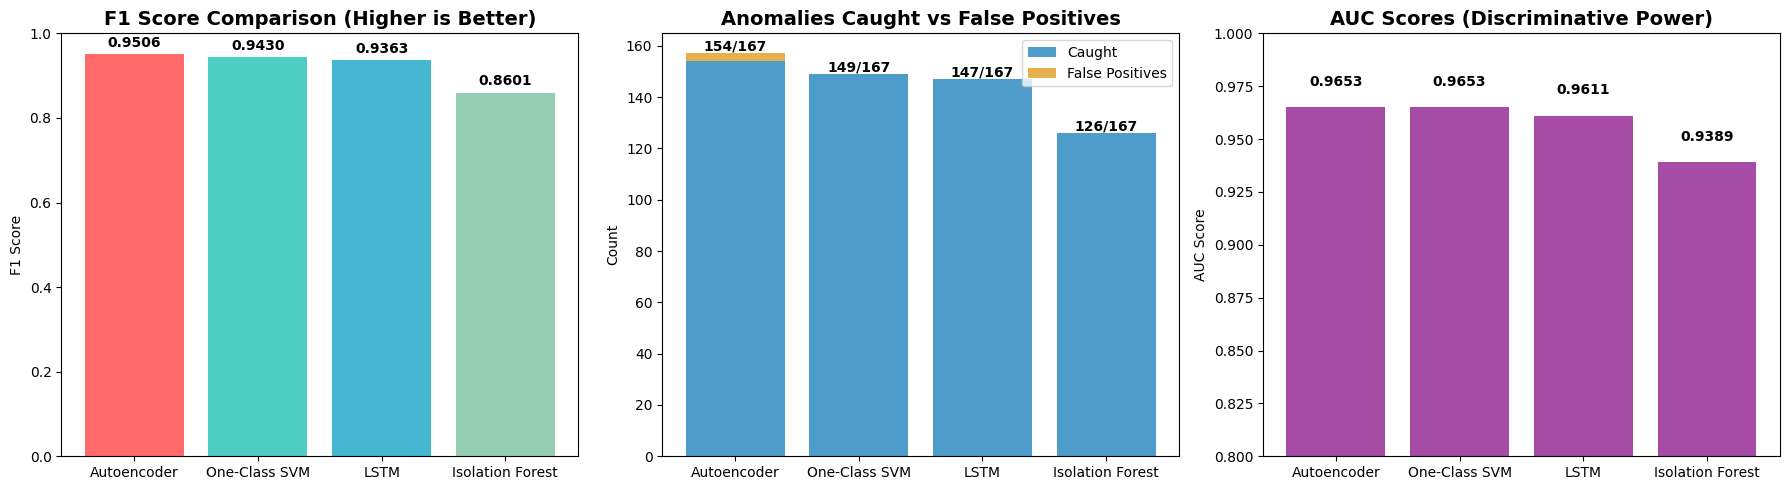

In [12]:
# FINAL MODEL COMPARISON

print("\n" + "="*90)
print("FINAL MODEL COMPARISON - BEST PERFORMING CONFIGURATIONS")
print("="*90)

# Collect best models from each type
best_models = []
for model_name, results in [
    ("Isolation Forest", isolation_forest_results),
    ("One-Class SVM", one_class_svm_results),
    ("LSTM", lstm_results),
    ("Autoencoder", autoencoder_results),
]:
    if results:
        best_model = max(results, key=lambda x: x["f1_score"])
        best_models.append({
            "model": model_name,
            "training_days": best_model["training_days"],
            "f1_score": best_model["f1_score"],
            "precision": best_model["precision"],
            "recall": best_model["recall"],
            "accuracy": best_model["accuracy"],
            "balanced_accuracy": best_model["balanced_accuracy"],
            "auc": best_model["auc"],
            "true_positives": best_model["true_positives"],
            "false_positives": best_model["false_positives"],
            "false_negatives": best_model["false_negatives"],
            "true_negatives": best_model["true_negatives"],
        })

# If nothing to compare, stop gracefully
comparison_df = pd.DataFrame(best_models)
if comparison_df.empty:
    print("No models available for final comparison.")
else:
    # Extra metrics
    comparison_df["anomalies_caught"] = (
        comparison_df["true_positives"].astype(str)
        + "/"
        + (comparison_df["true_positives"] + comparison_df["false_negatives"]).astype(str)
    )
    denom = (comparison_df["false_positives"] + comparison_df["true_negatives"]).replace(0, np.nan)
    comparison_df["false_positive_rate"] = comparison_df["false_positives"] / denom
    comparison_df["detection_rate"] = comparison_df["true_positives"] / (
        comparison_df["true_positives"] + comparison_df["false_negatives"]
    )

    # Sort by F1
    comparison_df = comparison_df.sort_values("f1_score", ascending=False)

    # Print table
    print(f"{'Model':<20} {'Days':<6} {'F1':<8} {'Precision':<10} {'Recall':<10} "
          f"{'Caught':<12} {'FP':<6} {'AUC':<8} {'Bal Acc':<8}")
    print("-"*90)
    for _, row in comparison_df.iterrows():
        print(f"{row['model']:<20} {row['training_days']:<6} {row['f1_score']:<8.4f} "
              f"{row['precision']:<10.4f} {row['recall']:<10.4f} "
              f"{row['anomalies_caught']:<12} {row['false_positives']:<6} "
              f"{row['auc']:<8.4f} {row['balanced_accuracy']:<8.4f}")

    # Key insights
    print("\n" + "="*90)
    print("KEY INSIGHTS")
    print("="*90)
    print(f"\n Best Overall: {comparison_df['model'].iloc[0]} ({comparison_df['training_days'].iloc[0]}d)")
    print(f"   F1: {comparison_df['f1_score'].iloc[0]:.4f}, Precision: {comparison_df['precision'].iloc[0]:.4f}, "
          f"Recall: {comparison_df['recall'].iloc[0]:.4f}")

    perfect_prec_models = comparison_df[comparison_df["precision"] == 1.0]["model"].tolist()
    print(f"\n Perfect Precision: {', '.join(perfect_prec_models) if perfect_prec_models else 'None'}")
    idx_max_recall = comparison_df["recall"].idxmax()
    print(f"Highest Recall: {comparison_df.loc[idx_max_recall, 'model']} "
          f"({comparison_df.loc[idx_max_recall, 'recall']:.4f})")

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ax1, ax3, ax4 = axes

    models = comparison_df["model"].tolist()
    f1_scores = comparison_df["f1_score"].values

    # Bar colors sized to number of models
    palette = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4']
    colors = palette[:len(models)]

    # F1 Score Comparison
    bars = ax1.bar(models, f1_scores, color=colors)
    ax1.set_title("F1 Score Comparison (Higher is Better)", fontsize=14, fontweight="bold")
    ax1.set_ylabel("F1 Score")
    ax1.set_ylim(0, 1.0)
    for bar, score in zip(bars, f1_scores):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{score:.4f}",
                 ha="center", va="bottom", fontweight="bold")

    # Anomalies Caught vs False Positives
    caught = (comparison_df["true_positives"]).astype(int).tolist()
    total_anomalies = (comparison_df["true_positives"] + comparison_df["false_negatives"]).astype(int).tolist()
    ax3.bar(models, caught, label="Caught", alpha=0.7)
    ax3.bar(models, comparison_df["false_positives"], bottom=caught, label="False Positives", alpha=0.7)
    ax3.set_title("Anomalies Caught vs False Positives", fontsize=14, fontweight="bold")
    ax3.set_ylabel("Count")
    ax3.legend()
    for i, (catch, fp, total) in enumerate(zip(caught, comparison_df["false_positives"], total_anomalies)):
        ax3.text(i, catch + fp + 1, f"{catch}/{total}", ha="center", fontweight="bold")

    # AUC Scores
    ax4.bar(models, comparison_df["auc"], color="purple", alpha=0.7)
    ax4.set_title("AUC Scores (Discriminative Power)", fontsize=14, fontweight="bold")
    ax4.set_ylabel("AUC Score")
    ax4.set_ylim(0.8, 1.0)
    for i, auc in enumerate(comparison_df["auc"]):
        ax4.text(i, auc + 0.01, f"{auc:.4f}", ha="center", fontweight="bold")

    plt.tight_layout()
    plt.show()
